<a href="https://colab.research.google.com/github/Moquiuti/fundamentos-ia-investigando-algoritmos-abordagens-machine-learning/blob/main/ajustando_modelos_de_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importância das variáveis:
s5     0.315629
bmi    0.276249
bp     0.087085
s6     0.070775
age    0.057496
s2     0.055368
s3     0.051191
s1     0.047251
s4     0.027056
sex    0.011901
dtype: float64


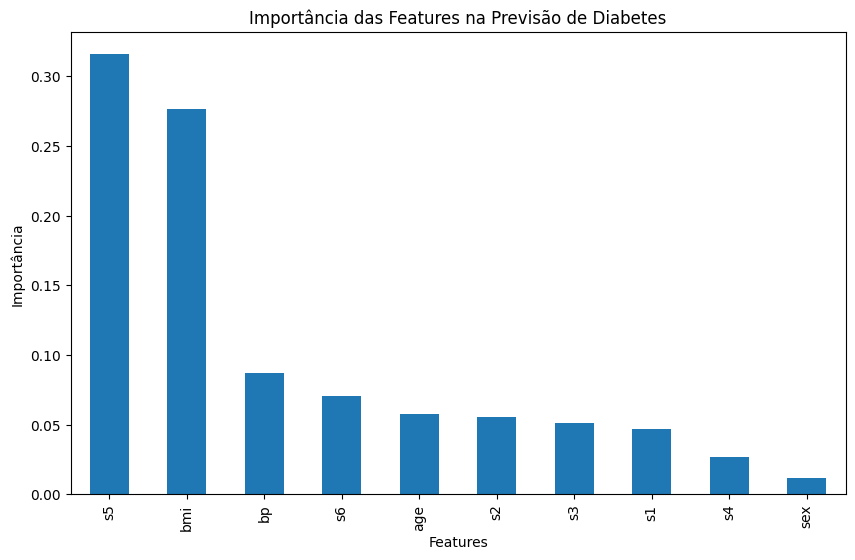

In [1]:
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# Carregando dataset de diabetes
diabetes = load_diabetes()

X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

# Treinando modelo para analisar importância das variáveis
modelo_rf = RandomForestRegressor(random_state=42)
modelo_rf.fit(X, y)

# Importância das features
importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=False)

print("Importância das variáveis:")
print(importancias)

# Gráfico
plt.figure(figsize=(10, 6))
importancias.plot(kind='bar')
plt.title('Importância das Features na Previsão de Diabetes')
plt.ylabel('Importância')
plt.xlabel('Features')
plt.show()

In [2]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Carregando um dataset de classificação
iris = load_iris()

X = iris.data
y = iris.target

# Separando treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Definindo o modelo
modelo = DecisionTreeClassifier(random_state=42)

# Definindo os hiperparâmetros para teste
param_grid = {
    'max_depth': [2, 3, 4, 5, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Aplicando Grid Search
grid_search = GridSearchCV(
    estimator=modelo,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

# Melhor modelo encontrado
melhor_modelo = grid_search.best_estimator_

# Previsões
y_pred = melhor_modelo.predict(X_test)

print("Melhores hiperparâmetros encontrados:")
print(grid_search.best_params_)

print("\nAcurácia no conjunto de teste:")
print(accuracy_score(y_test, y_pred))

print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Melhores hiperparâmetros encontrados:
{'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}

Acurácia no conjunto de teste:
1.0

Relatório de classificação:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

